In [4]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


In [9]:
import pandas as pd
import numpy as np

# Setting seed for reproducible dummy data matching video output
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
categories = ['Electronics', 'Clothing', 'Home Goods', 'Sports', 'Books']
regions = ['North', 'East', 'South', 'West']

data = {
    'Date': np.random.choice(dates, 100),
    'Category': np.random.choice(categories, 100),
    'Sales': np.random.uniform(300, 1500, 100),
    'Quantity': np.random.randint(1, 16, 100),
    'Profit': np.random.uniform(50, 500, 100),
    'Region': np.random.choice(regions, 100)
}

df = pd.DataFrame(data).sort_values('Date').reset_index(drop=True)

In [10]:
# Synthetic data banane ke baad yeh line add karein:
df.to_csv('retail_sales.csv', index=False)

In [11]:
# Cell 1: Load dataset
df = pd.read_csv('retail_sales.csv')

In [12]:
# Cell 2: Display first 10 rows
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,2023-01-02,Electronics,1213.943538,1,85.305372,West
1,2023-01-02,Books,1235.850655,8,123.320492,South
2,2023-01-02,Home Goods,569.123171,3,457.407789,East
3,2023-01-02,Home Goods,1058.766997,5,363.188393,South
4,2023-01-03,Sports,1482.780545,15,407.833788,North
5,2023-01-03,Clothing,1091.980855,1,94.025372,North
6,2023-01-04,Books,1380.501669,13,335.792143,West
7,2023-01-04,Electronics,690.479638,12,95.350101,North
8,2023-01-04,Sports,1082.353511,12,482.535754,North
9,2023-01-06,Clothing,1154.615066,7,138.106011,East


In [13]:
# Data Type Conversion and Cleaning
print("=== DATA CLEANING AND TYPE CONVERSION ===")

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract additional time features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

# Ensure numeric columns are properly formatted
numeric_columns = ['Sales', 'Quantity', 'Profit']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")

=== DATA CLEANING AND TYPE CONVERSION ===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity              int64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object

Date range: 2023-01-02 00:00:00 to 2023-04-10 00:00:00


In [14]:
# Basic Statistical Summary
print("=== STATISTICAL SUMMARY ===")
print("Descriptive Statistics for Numerical Columns:")
print(df[['Sales', 'Quantity', 'Profit']].describe())

=== STATISTICAL SUMMARY ===
Descriptive Statistics for Numerical Columns:
             Sales    Quantity      Profit
count   100.000000  100.000000  100.000000
mean    877.086395    8.130000  264.234253
std     342.234342    4.409941  130.847587
min     306.073901    1.000000   56.477070
25%     586.896965    4.750000  144.866099
50%     908.863249    8.000000  273.819230
75%    1129.412524   12.000000  367.876569
max    1482.780545   15.000000  495.727314


In [15]:
print("\nCategory-wise Summary:")
category_summary = df.groupby('Category').agg({
    'Sales': ['count', 'sum', 'mean', 'std'],
    'Profit': ['sum', 'mean'],
    'Quantity': ['sum', 'mean']
}).round(2)
print(category_summary)


Category-wise Summary:
            Sales                              Profit         Quantity      
            count       sum     mean     std      sum    mean      sum  mean
Category                                                                    
Books          17  15141.32   890.67  395.44  4058.90  238.76      125  7.35
Clothing       12  12283.09  1023.59  292.75  3063.35  255.28       82  6.83
Electronics    27  22529.08   834.41  310.80  7693.81  284.96      244  9.04
Home Goods     21  18690.92   890.04  321.43  5159.44  245.69      167  7.95
Sports         23  19064.22   828.88  381.73  6447.93  280.34      195  8.48


In [16]:
print("\nRegion-wise Summary:")
region_summary = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
print(region_summary)


Region-wise Summary:
           Sales           Profit        
             sum    mean      sum    mean
Region                                   
East    19070.11  908.10  4923.44  234.45
North   29304.61  861.90  9307.17  273.74
South   21290.90  887.12  6881.35  286.72
West    18043.02  859.19  5311.47  252.93


In [17]:
# Cell 6: Monthly Sales Trend Analysis
print("=== MONTHLY SALES TREND ANALYSIS ===")

# Calculate monthly sales
monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

monthly_sales = monthly_sales.sort_values('Month')
print("Monthly Sales Summary:")
print(monthly_sales)

=== MONTHLY SALES TREND ANALYSIS ===
Monthly Sales Summary:
   Month MonthName         Sales       Profit  Quantity
0      1   January  26848.848333  7177.011921       218
1      2  February  23709.659682  7938.676726       243
2      3     March  30066.850734  9140.244312       279
3      4     April   7083.280766  2167.492357        73


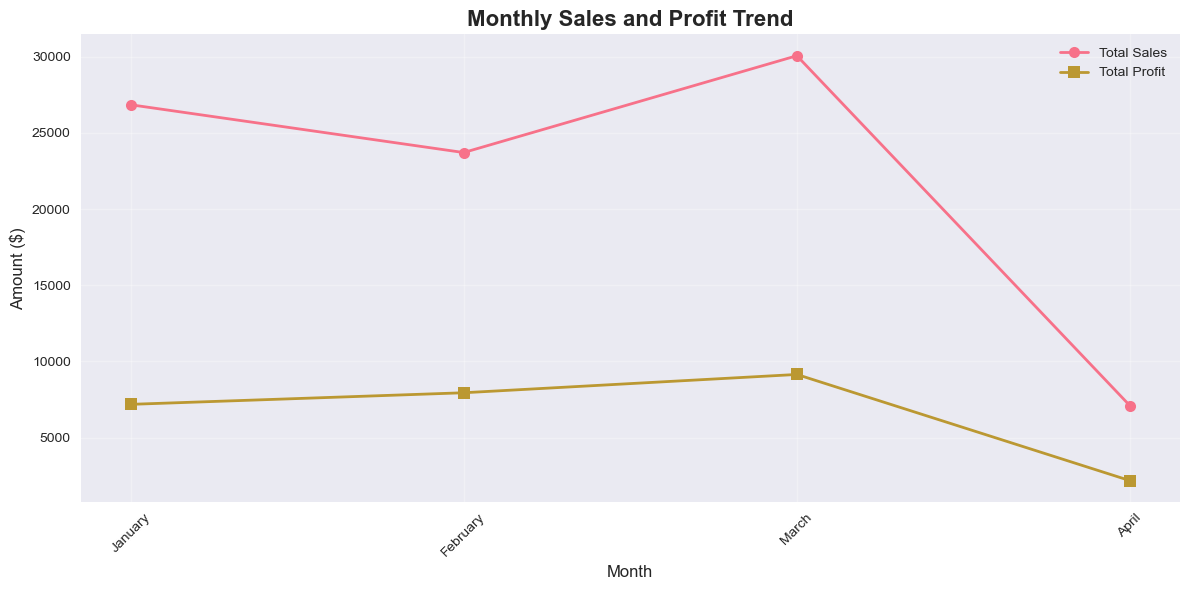

In [18]:
# Visualization 1: Monthly Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'], 
         marker='o', linewidth=2, markersize=8, label='Total Sales')
plt.plot(monthly_sales['MonthName'], monthly_sales['Profit'], 
         marker='s', linewidth=2, markersize=8, label='Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Category Performance Analysis
print("=== CATEGORY PERFORMANCE ANALYSIS ===")

category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False)

print("Category Performance (Sorted by Sales):")
print(category_performance)

=== CATEGORY PERFORMANCE ANALYSIS ===
Category Performance (Sorted by Sales):
                    Sales       Profit  Quantity
Category                                        
Electronics  22529.084559  7693.808965       244
Sports       19064.219224  6447.926899       195
Home Goods   18690.923330  5159.437874       167
Books        15141.318702  4058.899778       125
Clothing     12283.093699  3063.351801        82


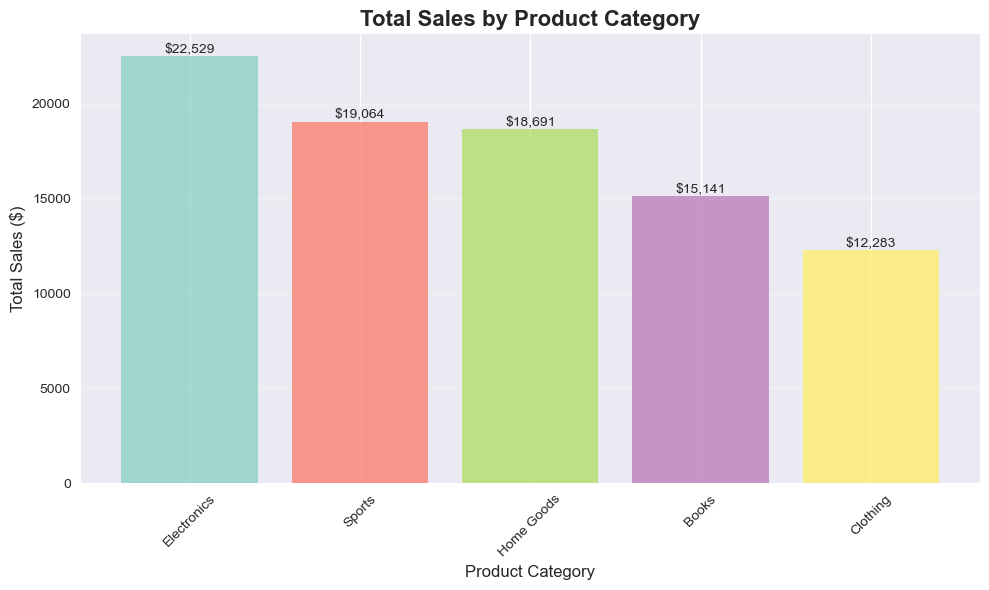

In [20]:
# Visualization 2: Top Categories by Sales
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))
bars = plt.bar(category_performance.index, category_performance['Sales'], 
               color=colors, alpha=0.8)

# Add value Labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}', ha='center', va='bottom')

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Cell 8: Regional Performance Analysis
print("=== REGIONAL PERFORMANCE ANALYSIS ===")

regional_performance = df.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean']
}).round(2)

print("Regional Performance:")
print(regional_performance)

=== REGIONAL PERFORMANCE ANALYSIS ===
Regional Performance:
           Sales                 Profit        
             sum    mean count      sum    mean
Region                                         
East    19070.11  908.10    21  4923.44  234.45
North   29304.61  861.90    34  9307.17  273.74
South   21290.90  887.12    24  6881.35  286.72
West    18043.02  859.19    21  5311.47  252.93


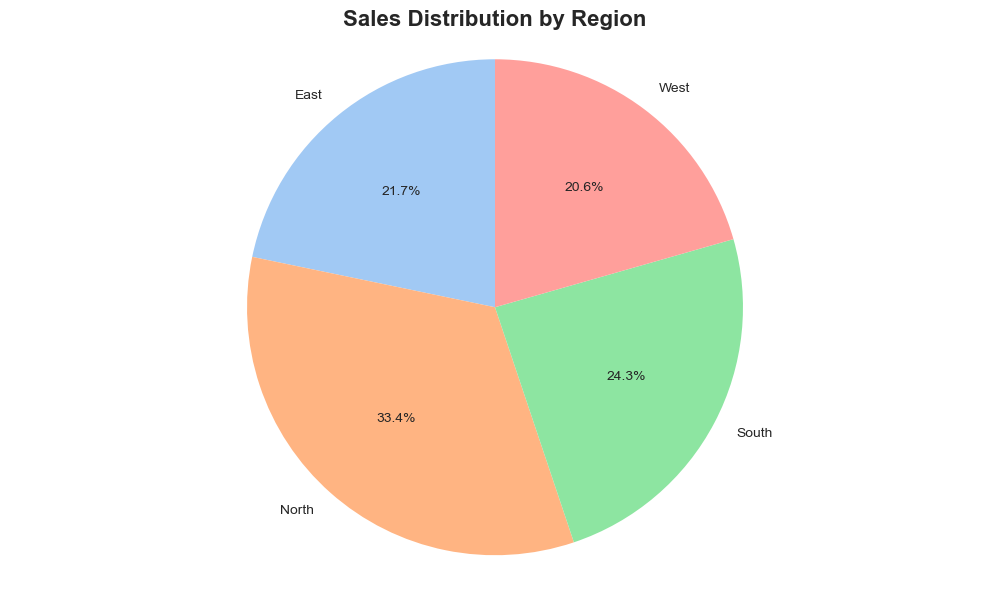

In [22]:
# Visualization 3: Regional Sales Distribution
plt.figure(figsize=(10, 6))
regional_data = df.groupby('Region')['Sales'].sum()
plt.pie(regional_data, labels=regional_data.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette("pastel"))
plt.title('Sales Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

=== DAY OF WEEK ANALYSIS ===
Average Performance by Day of Week:
            Sales  Profit  Quantity
DayOfWeek                          
Monday     972.92  316.84      7.71
Tuesday    870.83  252.12      8.42
Wednesday  851.21  261.73      8.17
Thursday   907.73  189.69      8.67
Friday     900.39  232.07      7.62
Saturday   860.24  270.45      8.25
Sunday     779.79  297.63      8.25


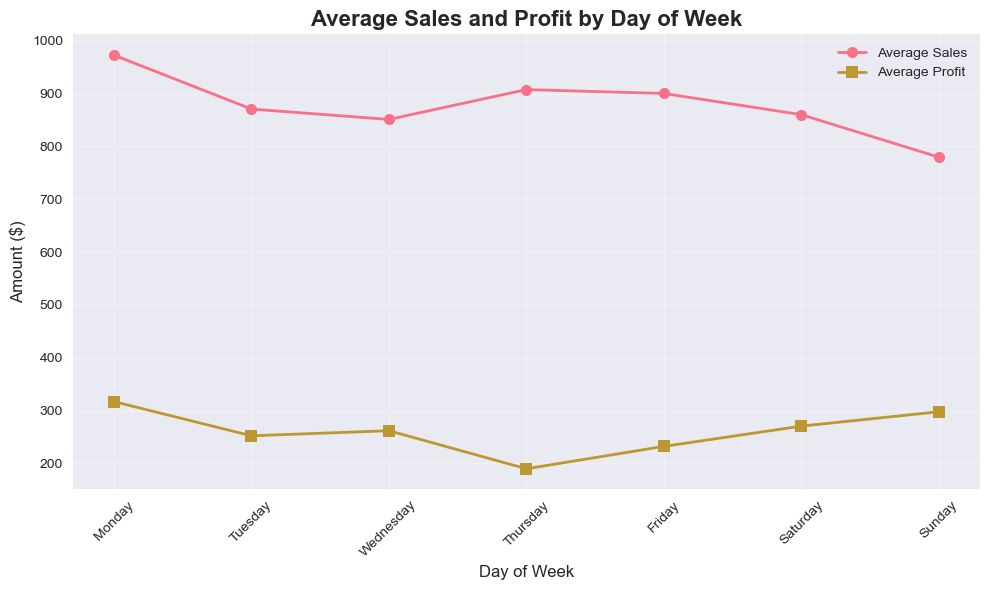

In [23]:
# Day of Week Analysis
print("=== DAY OF WEEK ANALYSIS ===")

# Define proper order for days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

daily_performance = df.groupby('DayOfWeek').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).round(2)

print("Average Performance by Day of Week:")
print(daily_performance)

# Visualization 4: Daily Sales Pattern
plt.figure(figsize=(10, 6))
plt.plot(daily_performance.index, daily_performance['Sales'], 
         marker='o', linewidth=2, markersize=8, label='Average Sales')
plt.plot(daily_performance.index, daily_performance['Profit'], 
         marker='s', linewidth=2, markersize=8, label='Average Profit')

plt.title('Average Sales and Profit by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== CORRELATION ANALYSIS ===
Correlation Matrix:
             Sales  Quantity    Profit     Month
Sales     1.000000  0.026632  0.040155 -0.166625
Quantity  0.026632  1.000000  0.157079 -0.010450
Profit    0.040155  0.157079  1.000000 -0.045986
Month    -0.166625 -0.010450 -0.045986  1.000000


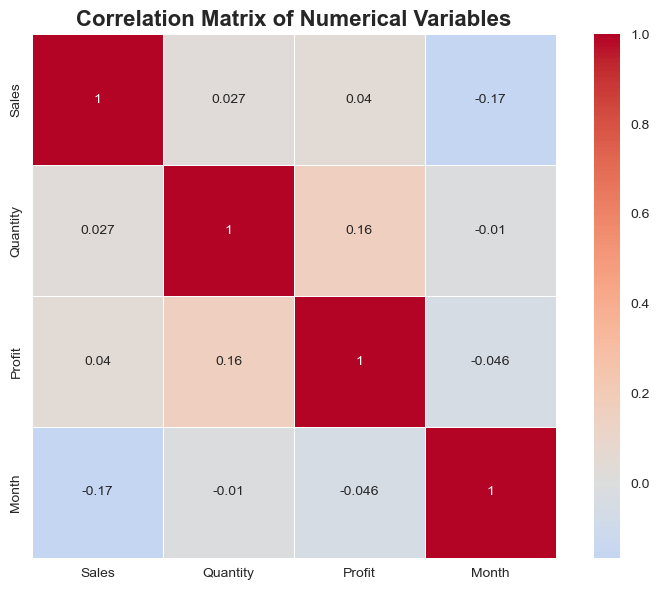

In [24]:
# Correlation Analysis
print("=== CORRELATION ANALYSIS ===")

# Select numerical columns for correlation
numerical_df = df[['Sales', 'Quantity', 'Profit', 'Month']]
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== 4-CHART RETAIL SALES DASHBOARD ===


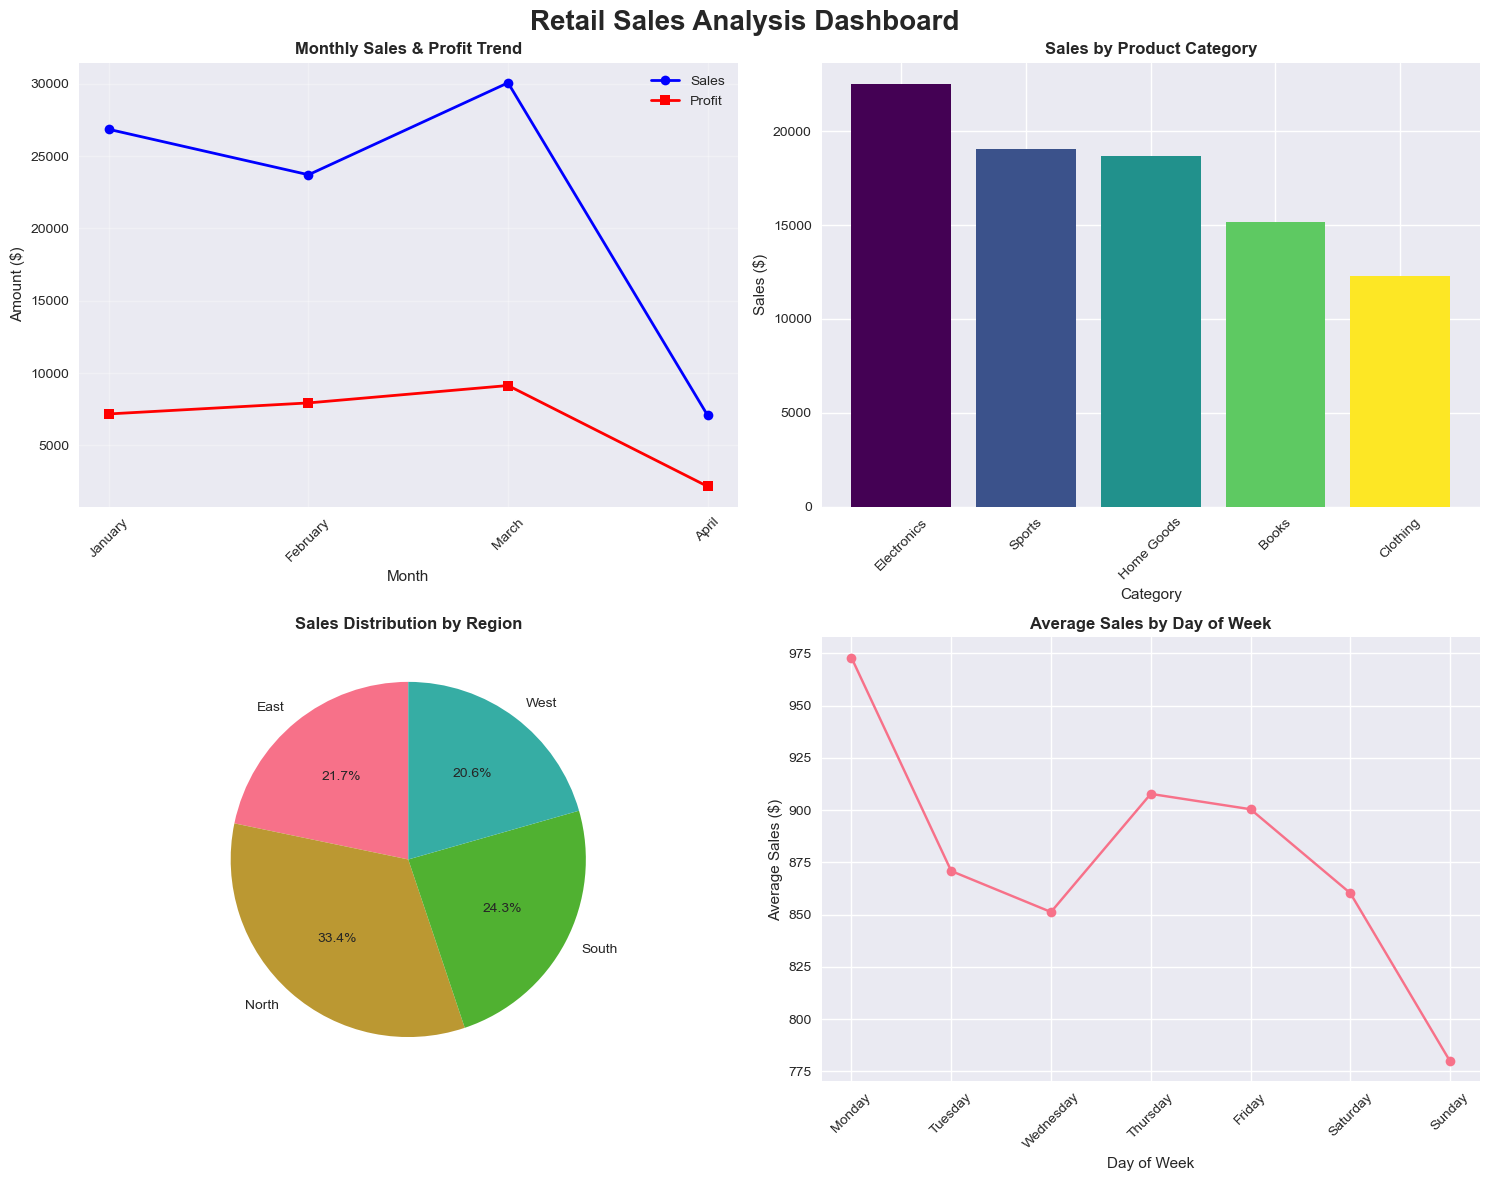

In [25]:
# 4-Chart Mini Dashboard
print("=== 4-CHART RETAIL SALES DASHBOARD ===")

# Create a 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Retail Sales Analysis Dashboard', fontsize=20, fontweight='bold')

# Chart 1: Monthly Sales Trend (Top-Left)
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Sales'], 
               marker='o', linewidth=2, color='blue', label='Sales')
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Profit'], 
               marker='s', linewidth=2, color='red', label='Profit')
axes[0,0].set_title('Monthly Sales & Profit Trend', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Amount ($)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2: Top Categories (Top-Right)
colors = plt.cm.viridis(np.linspace(0, 1, len(category_performance)))
bars = axes[0,1].bar(category_performance.index, category_performance['Sales'], color=colors)
axes[0,1].set_title('Sales by Product Category', fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3: Regional Sales Distribution (Bottom-Left)
axes[1,0].pie(regional_data, labels=regional_data.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Sales Distribution by Region', fontweight='bold')

# Chart 4: Daily Sales Pattern (Bottom-Right)
axes[1,1].plot(daily_performance.index, daily_performance['Sales'], marker='o', label='Average Sales')
axes[1,1].set_title('Average Sales by Day of Week', fontweight='bold')
axes[1,1].set_xlabel('Day of Week')
axes[1,1].set_ylabel('Average Sales ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Key Insights and Business Recommendations
print("=== KEY INSIGHTS AND RECOMMENDATIONS ===")

print("\n📊 KEY FINDINGS:")
print("1. Top Performing Category:", category_performance.index[0])
print("2. Best Performing Region:", regional_data.idxmax())
print("3. Highest Sales Month:", monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'MonthName'])
print("4. Best Day of Week:", daily_performance['Sales'].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("6. Total Annual Profit: ${:,.2f}".format(df['Profit'].sum()))

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("1. Focus marketing efforts on", category_performance.index[0], "category")
print("2. Investigate performance in lower-performing regions")
print("3. Plan promotions around", daily_performance['Sales'].idxmax(), "to maximize sales")
print("4. Allocate inventory based on monthly trend patterns")
print("5. Monitor correlation between quantity and profit for pricing strategy")

print("\n📈 PROFITABILITY ANALYSIS:")
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"Overall Profit Margin: {profit_margin:.2f}%")

# Category profit margins
category_margins = (category_performance['Profit'] / category_performance['Sales']) * 100
print("\nProfit Margins by Category:")
for category, margin in category_margins.items():
    print(f"  {category}: {margin:.2f}%")

=== KEY INSIGHTS AND RECOMMENDATIONS ===

📊 KEY FINDINGS:
1. Top Performing Category: Electronics
2. Best Performing Region: North
3. Highest Sales Month: March
4. Best Day of Week: Monday
5. Total Annual Sales: $87,708.64
6. Total Annual Profit: $26,423.43

💡 BUSINESS RECOMMENDATIONS:
1. Focus marketing efforts on Electronics category
2. Investigate performance in lower-performing regions
3. Plan promotions around Monday to maximize sales
4. Allocate inventory based on monthly trend patterns
5. Monitor correlation between quantity and profit for pricing strategy

📈 PROFITABILITY ANALYSIS:
Overall Profit Margin: 30.13%

Profit Margins by Category:
  Electronics: 34.15%
  Sports: 33.82%
  Home Goods: 27.60%
  Books: 26.81%
  Clothing: 24.94%
